In [12]:
import sys
!{sys.executable} -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [15]:
import sys, pandas as pd
print(sys.executable)
print(pd.__version__)

/Library/Developer/CommandLineTools/usr/bin/python3
2.3.3


In [9]:
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


## Task 1: Identify Prediction and Target Variables

**Lecture Material:**
- Lecture 1 — *Problem Formulation*
- Lecture 2 — *Data Inspection*

---

### 1. Inspect the Dataset and Select the Target Variable

- Inspect the dataset and identify which column should be treated as the **target variable** for this assignment.

---

### 2. Justify the Prediction Objective

- Explain why the selected column represents the appropriate **prediction objective** in the context of the marketing campaign.
- Clearly connect your choice to the campaign’s business objective (e.g., conversion, customer response, revenue generation).

---

### 3. Identify and Reject Alternative Target Variables

- Identify **at least two other variables** that might appear to be valid prediction targets.
- For each variable:
  - Explain why it may initially seem appropriate.
  - Explain why it should **not** be treated as the prediction objective.



Given the situation. It can be determined that this is a classification problem since we are predicting whether the client will subscribe to a specific deposit.

Given the data. It can be determined that the "y" column is the target column since it responds directly to the question: "has the client subscribed to the term deposit". This is a binary value meaning only 2 possible outcomes. Making this a perfect target for logistic regression.

Another variable that might be seen as the target is the "poutcome" that specifies the outcome of the previous marketing campaign. One might believe this is the target since it also responds to the same question, the only issue is that at the time of taking the decision, we already know this output, hence we don't really want to predict it.

Finally, a variable that might lead to data leakage is that of "duration", this attribute highly affects the output of the duration and once the call is made, it is known whether the client will subscribe to the term deposit, providing no actual meaningful decision knowledge. Therefore, "this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model".

## Task 2: Data Loading and Exploration
- Load the dataset into a Pandas DataFrame
- Inspect the structure of the dataset: number of observations, number of features, data types and basic summary statistics.
- Identify which variables are numerical and which are categorical
- Analyze the distribution of the target variable and comment on potential class imbalance.
- Detect explicit and implicit missing values (e.g., special categories such as unknown).
- Visualize the distribution of at least:
–- two numerical variables; and
–- two categorical variables.
- Identify at least one variable that may require special consideration before modeling (e.g., due to distributional
properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.


Note: Exploratory analysis is not a checklist of plots. Each visualization or statistic should support a specific
observation or hypothesis about the data.

This is done before any operation learns from data but before we split the dataset to really understand the underlying distributions of the different variables.

In [17]:
import pandas as pd

In [23]:
#printing out the first 15 elements
df = pd.read_csv('bank-additional.csv', sep=';')
print(df.head(15))

    age            job   marital            education  default  housing  \
0    30    blue-collar   married             basic.9y       no      yes   
1    39       services    single          high.school       no       no   
2    25       services   married          high.school       no      yes   
3    38       services   married             basic.9y       no  unknown   
4    47         admin.   married    university.degree       no      yes   
5    32       services    single    university.degree       no       no   
6    32         admin.    single    university.degree       no      yes   
7    41   entrepreneur   married    university.degree  unknown      yes   
8    31       services  divorced  professional.course       no       no   
9    35    blue-collar   married             basic.9y  unknown       no   
10   25       services    single             basic.6y  unknown      yes   
11   36  self-employed    single             basic.4y       no       no   
12   36         admin.   

In [24]:
#maybe splitting the dataset is better to do before.

print("Shape:", df.shape)
print("\nData types:", df.dtypes)
print("\nSummary Statistics:", df.describe())



Shape: (4119, 21)

Data types: age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Summary Statistics:                age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000

the shape tells us there are 4119 rows and 21 columns (20 features and 1 target).

Furthermore, these statistics also display signs of skewness in age, duration campaign, pdays anf previous where the mean tends to exceed the median meaning a possible right skew. In addition, pdays is dominated by 999 which we infer is a special encoding for "not previously contacted"

In [25]:
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(include='object').columns.tolist()

print("Numerical variables:", numerical)
print("\nCategorical variables:", categorical)

Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


y
no     3668
yes     451
Name: count, dtype: int64

Class balance (%):
 y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


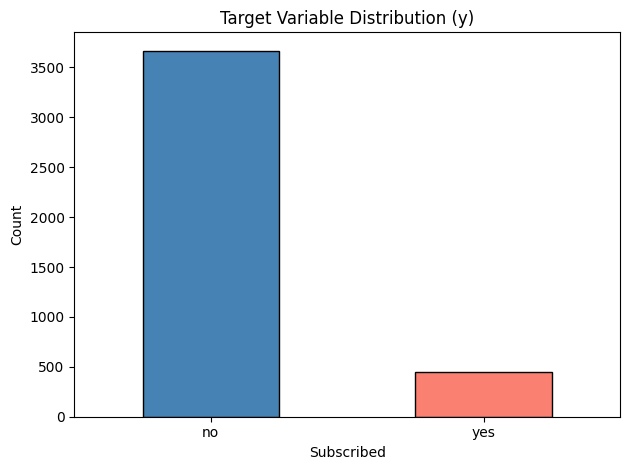

In [26]:
#Now we are going to loot at the target variable distribution to look at class imbalance.
import matplotlib.pyplot as plt

counts = df['y'].value_counts()
print(counts)
print("\nClass balance (%):\n", df['y'].value_counts(normalize=True) * 100)

counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Target Variable Distribution (y)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Takes these into account when separating the dataset.

Now we also want to understand which variables are missing:

In [27]:
print("Explicit nulls:\n", df.isnull().sum())

# Implicit missing values encoded as 'unknown'
print("\nImplicit missing values ('unknown'):")
for col in categorical:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")

Explicit nulls:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


Here we see that there are no explicit missing values but there are implicit.
Implicit missing variables might be an issue for education, housing, loan (<5%) and especially default.

The value of "unknowns" for default is too high so we cannot drop the variables, better to use it as a different category.

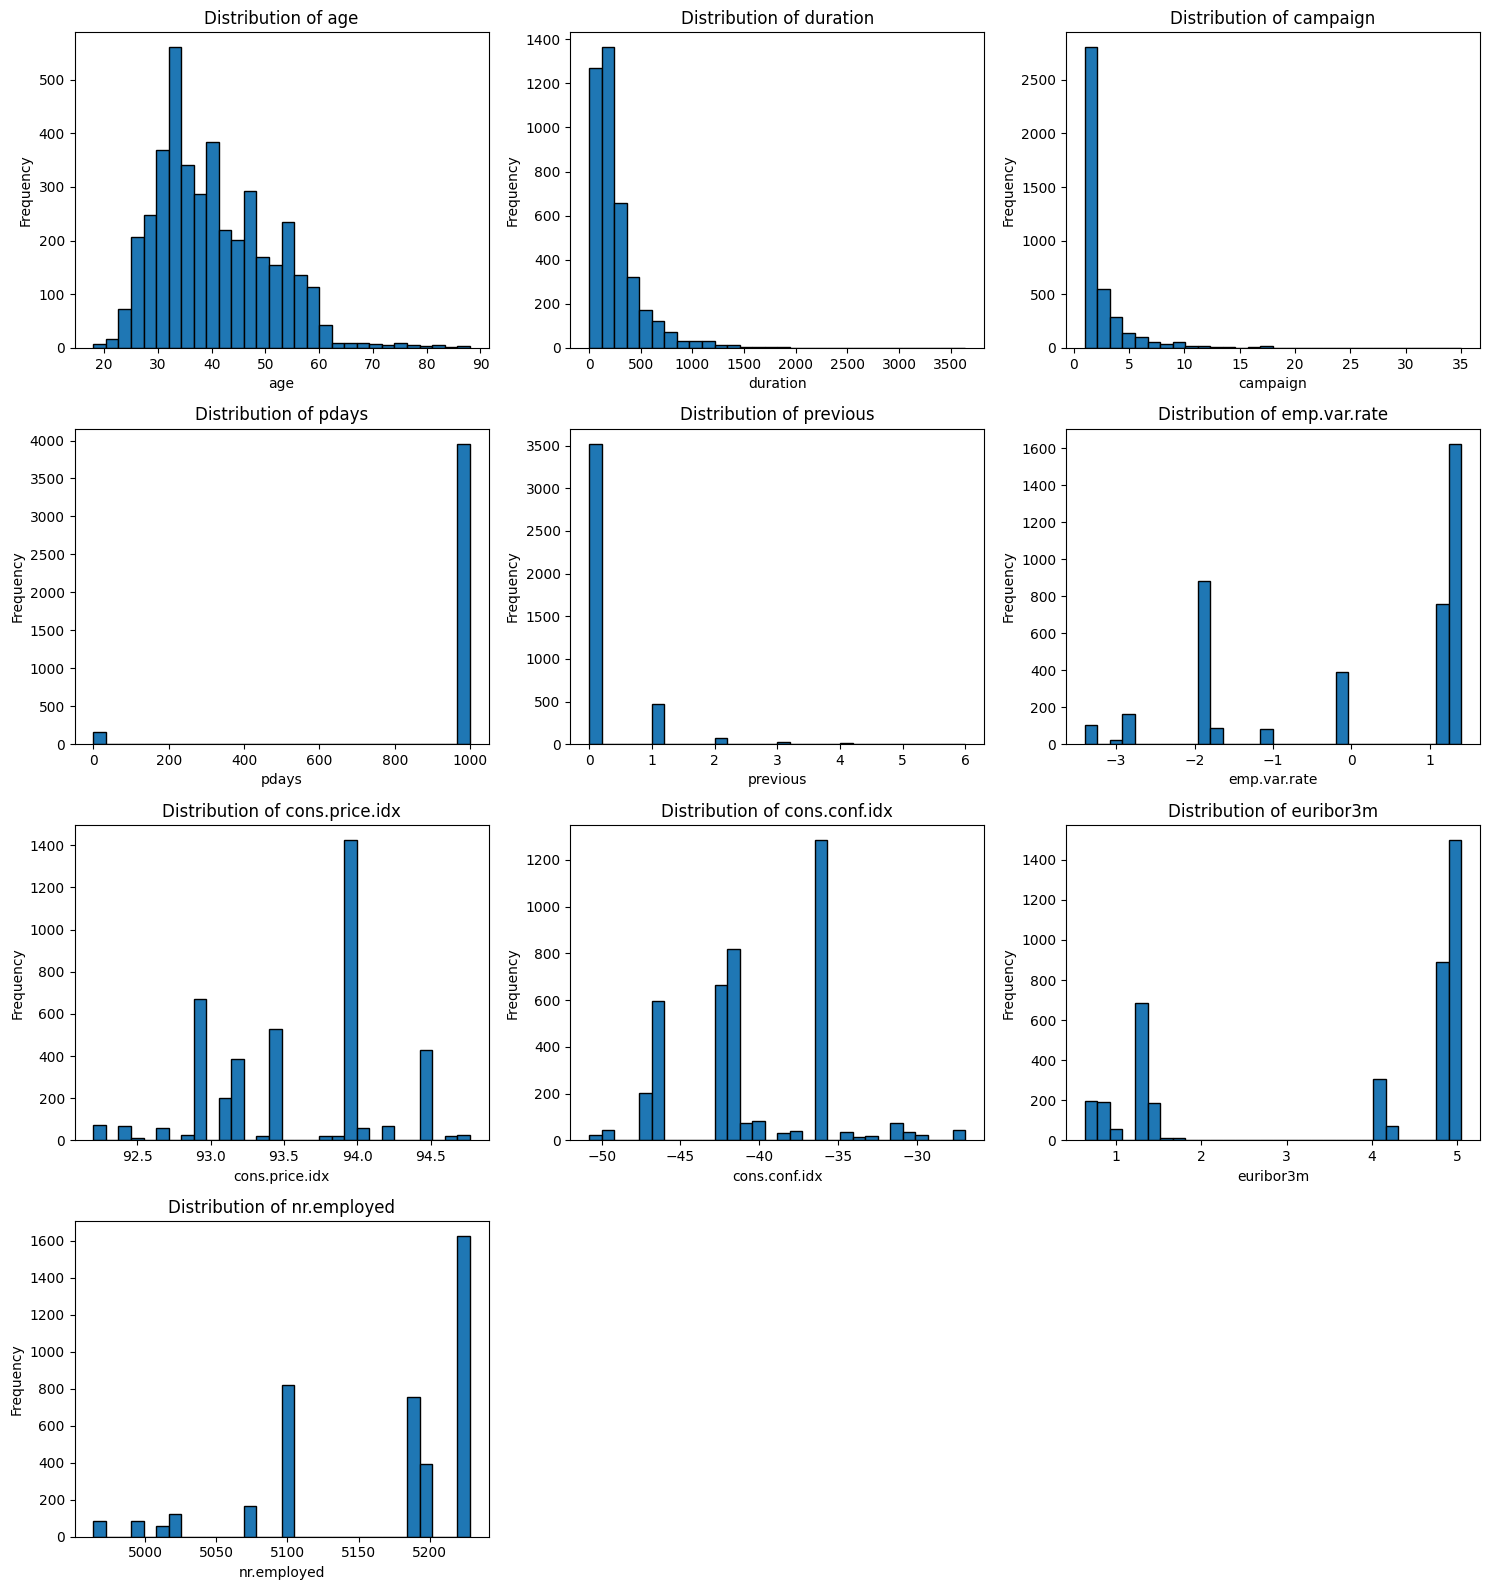

In [32]:
import math
# here we investigate two of the numerical values age and duration
#Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

numerical_vars= ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

n_variables= len(numerical_vars)

cols=3
rows= math.ceil(n_variables/cols)


fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_vars):
    df[col].plot(
        kind='hist',
        bins=30,
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

It is important that we consider the skewness of duration, campaign previous and pdays. This might affect the results.

In [29]:
#now we do the same but for categorical values:

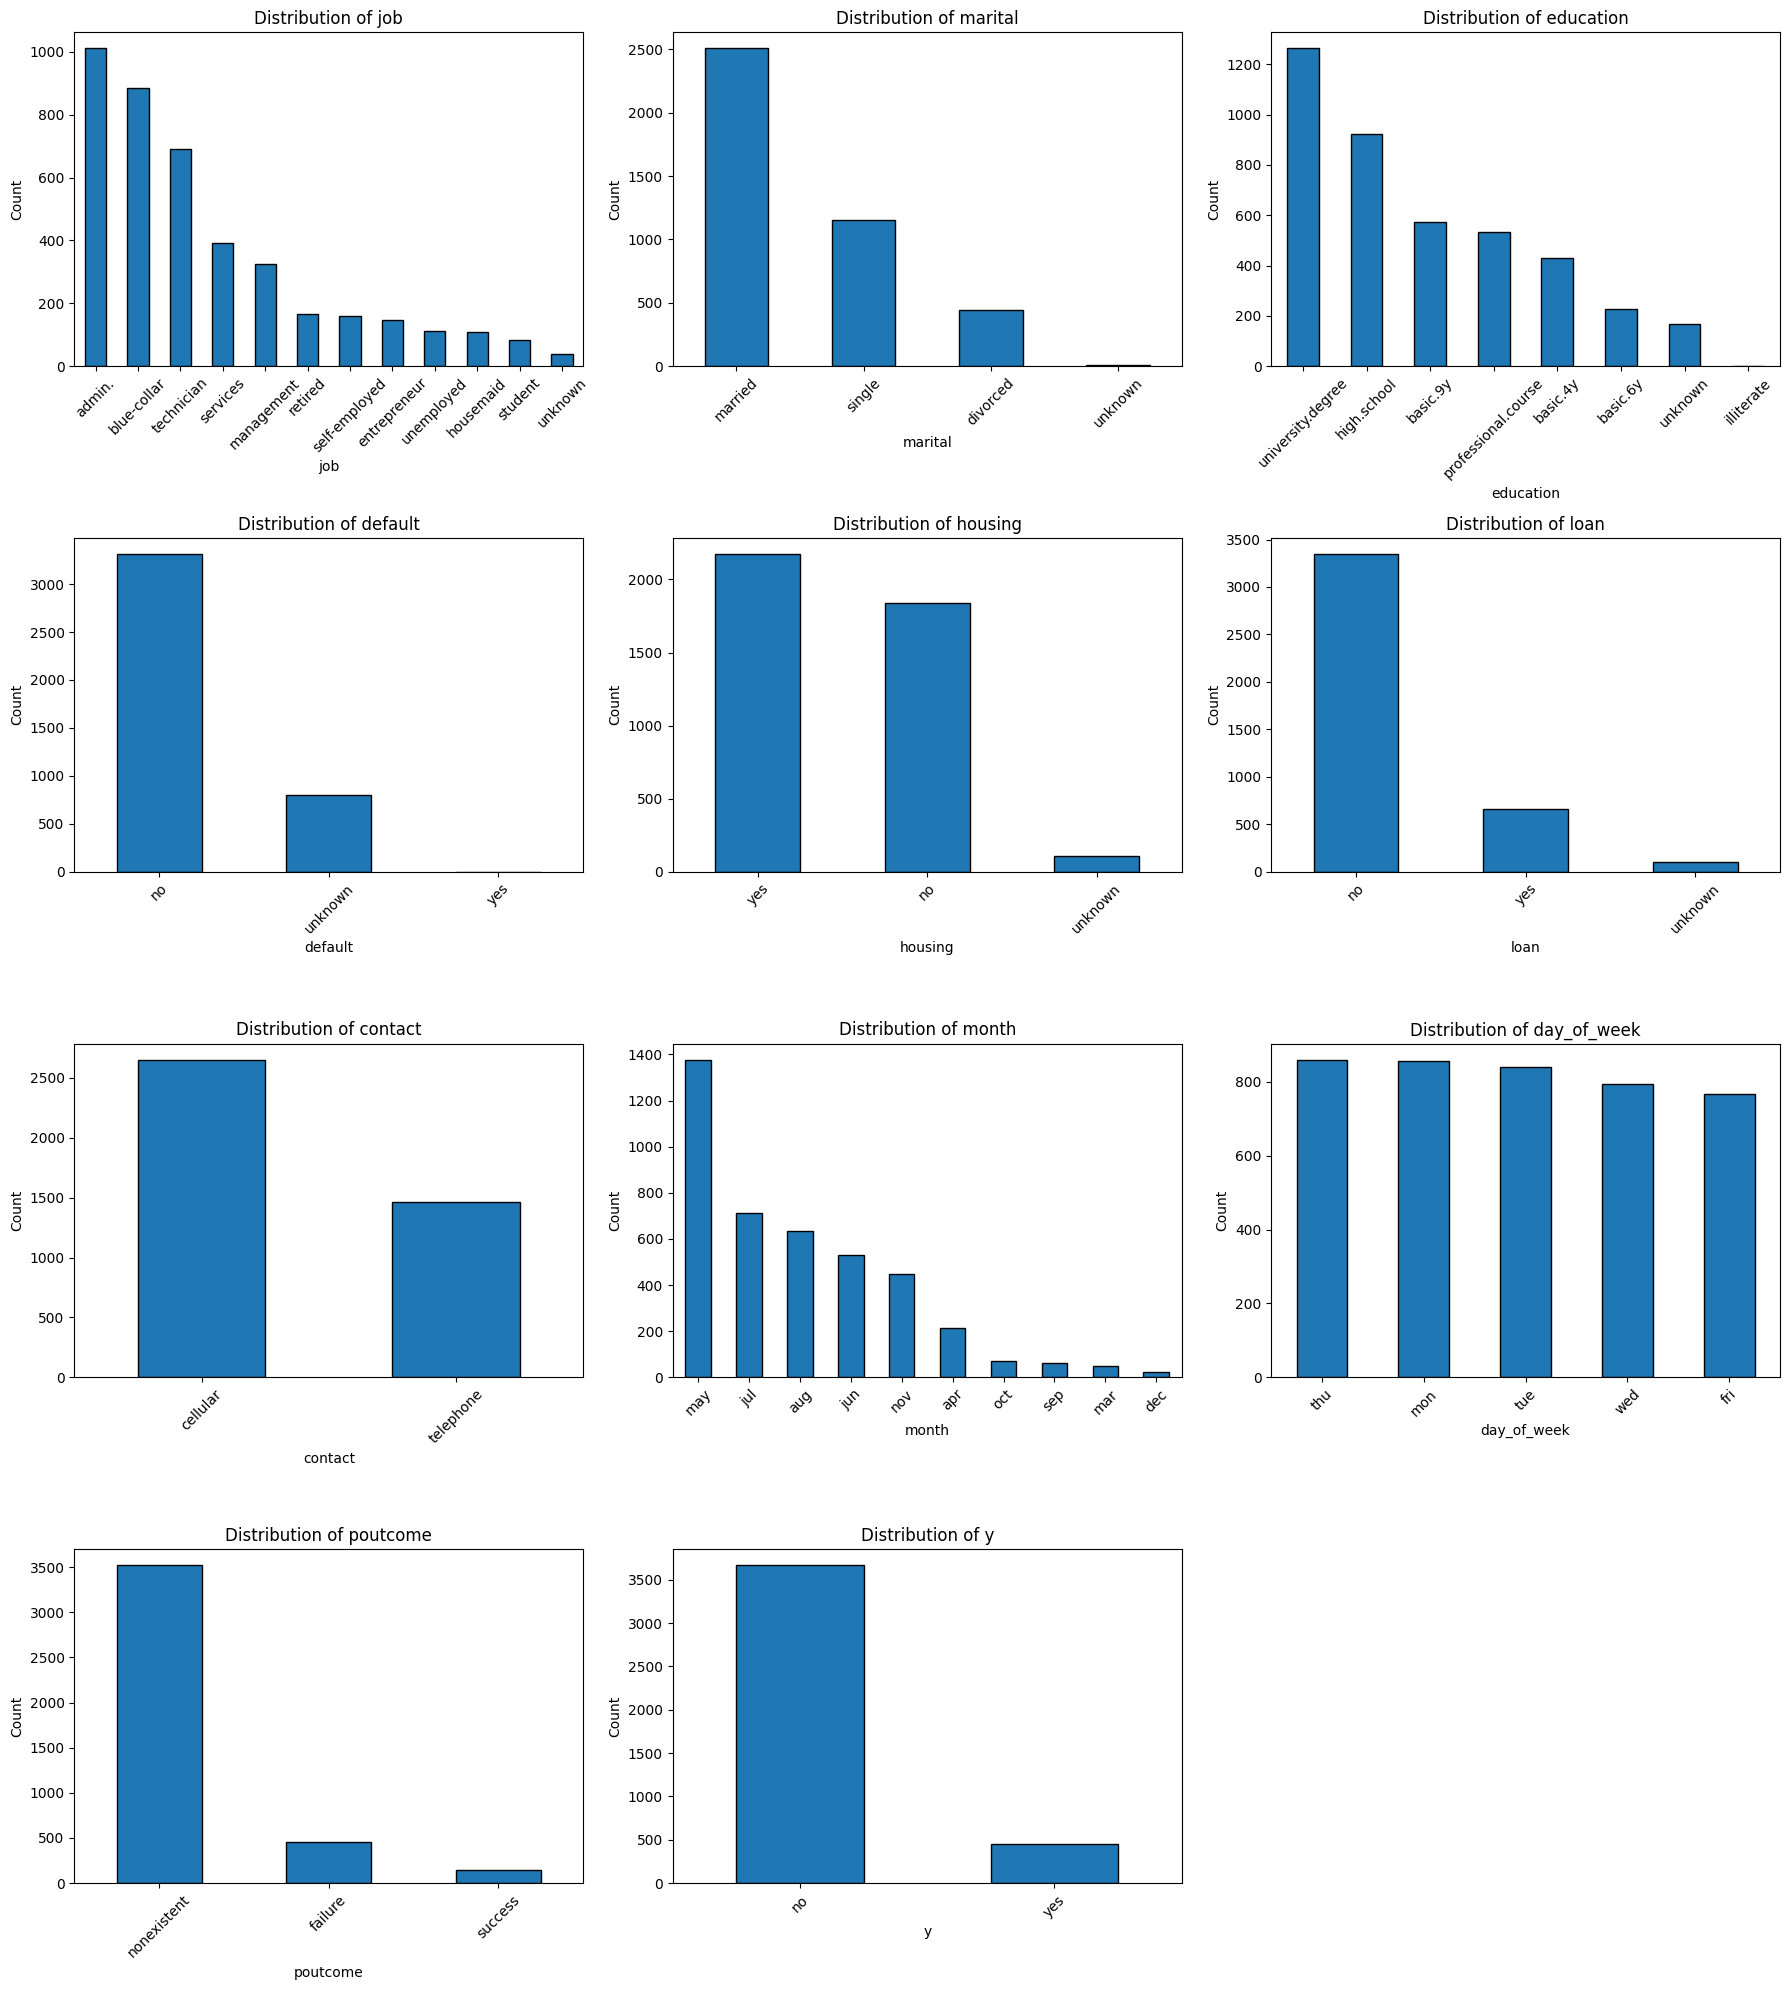

In [33]:
import matplotlib.pyplot as plt
import math

categorical_vars = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week',
    'poutcome', 'y'
]

n = len(categorical_vars)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From these graphs we can see there is a great class imbalance, for default, most of the values are "no". This low variance may lead to low predictive power.

Other categories that also have imbalance are:
- marital status
- job
- education
- month
- poutcome
- y

As aforementioned, the variable that requires special attention is duration. This is because it is highly right skewed and contains extreme values. Nevertheless, the main thing that should trigger response is the fact that once we know the duration of the call, we know whether the client has or hasnt taken the deposit.

## Step 3: Data Splitting.
Lecture material: Lecture 2 (Data Splitting and Leakage), Lecture 9 (ML Pipeline). LECTURE 8
- Split the dataset into training, validation, and test sets.
- Justify your choice of proportions for each split.
- Perform stratified splitting with respect to the target variable and explain why stratification is necessary for this dataset.
- Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage would arise if splitting were performed later.

Note: A recommended strategy is to first split the dataset into a training set and a temporary set, and then


split the temporary set into validation and test sets. Use the stratify argument of train test split where
appropriate.

This has to be done befora any operation that learns from data.
It is also always done before steps that compute distributional statistics, e.g., feature scaling, imputation, encoding,
feature selection, dimensionality reduction, model training (SESSION 8)

In this case, stratification is important since many of the classes seem to be unbalanced. Therefore, we will use stratified splitting on 'y' preserving class proportions in the split sets.